> **Note:** This environment variable is required for fully deterministic CuBLAS ops on CUDA >= 10.2 when `reproducible=True` is set below. Without it, PyTorch raises a `RuntimeError` instead of training deterministically. It must be set before `torch` is imported. See the [README FAQ](../../README.md#reproducibility-and-cublas_workspace_config) for details.

In [ ]:
%env CUBLAS_WORKSPACE_CONFIG=:16:8

### Disclaimer

This tutorial assumes that you have already familiarized yourself with the Autoencodix pipeline and thus only briefly touches on topics like data preparation and training your Autoencodix models.
If you are not yet familiar with these topics, the other tutorial notebooks in this repo are a good reference.

---

## Overview

Hyperparameter optimization allows you to systematically search over model parameters such as batch size, learning rate, network depth, and regularization strength. Instead of choosing these values manually, a hyperparameter optimization (HPO) framework like Optuna can be used to sample different configurations, run the model, evaluate it, and use the results to guide future trials.

Each trial follows this workflow:

1. Build a model configuration from sampled hyperparameters.
2. Train the model on the provided dataset.
3. Evaluate the learned embedding on downstream machine-learning tasks or other metrics like reconstruction loss.
4. Report evaluation metrics back to the optimizer.

The optimizer then uses an optimization algorithm to efficiently decide which hyperparameters to try next.

---

# Hyperparameter Optimization with Autoencodix using Optuna

This tutorial explains how to perform hyperparameter optimization (HPO) for Autoencodix models using Optuna. More information and documentation can be found here: https://optuna.org/. The goal is to automatically find good training settings for a chosen architecture by evaluating many different configurations and selecting the one with the best (downstream) performance.

Prerequisites:
 * training data
 * an Autoencodix model, e.g. Vanillix, Ontix, etc.

This tutorial covers all the necessary steps:
  * defining an objective function and the search space
  * running the optimization study
  * visualizing the results
  * and finally retrieving the best configuration

---



## Step 0: Install Optuna

To install Optuna from pip:

```
pip install optuna plotly
```
Note: `plotly` is installed for Optuna's built-in visualizations.


## Step 1: Defining the Objective Function and Configuration Space

### Objective Function

The core of the optimization is the objective function. This function defines what happens in a single trial.
Unlike other frameworks where the search space is defined separately, Optuna defines the configuration space dynamically inside the objective function using the `trial` object.

For each trial proposed by the optimizer, the objective function:

1. Samples hyperparameters like batch size, dropout probability, and learning rate using methods like `trial.suggest_int` or `trial.suggest_float`.
2. Instantiates and trains the model with the sampled configuration on the dataset.
3. Evaluates the learned embedding by computing performance metrics such as downstream performance and reconstruction loss.
4. Returns the metric to be optimized back to Optuna.

We can also store additional metrics that we don't optimize for directly (e.g., tracking reconstruction loss while optimizing for downstream performance) using `trial.set_user_attr`.

---


In [11]:
import optuna

#metric = "downstream_performance"
metric = "reconstruction_loss"

def objective(trial):
	## Fixed params
	epochs = 100
	checkpoint_interval = 25
	loss_reduction = "sum"
	tasks = "condition"

	## Tunable params sampled by Optuna
	batch_size = trial.suggest_int("batch_size", 128, 4096)
	drop_p = trial.suggest_float("drop_p", 0.0, 0.9)
	enc_factor = trial.suggest_int("enc_factor", 1, 5)
	weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)
	beta = trial.suggest_float("beta", 1e-5, 10, log=True)
	learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
	n_layers = trial.suggest_int("n_layers", 2, 5)

	from autoencodix.data.datapackage import DataPackage
	from autoencodix.configs.vanillix_config import VanillixConfig
	import sklearn
	from sklearn import linear_model
	import autoencodix as acx
	from autoencodix.utils.example_data import raw_protein, raw_rna, annotation
	from autoencodix.configs.default_config import DataCase

	# Step 1.1 instantiating our model with a given configuration
    # Our dataset
	my_datapackage = DataPackage(
    	multi_bulk={"rna": raw_rna, "protein": raw_protein},
    	annotation={"paired": annotation},
	)

    # The sampled configuration
	myconfig = VanillixConfig(
			## Fixed params
			data_case=DataCase.MULTI_BULK,
			epochs=epochs,
			checkpoint_interval= checkpoint_interval,
			loss_reduction= loss_reduction,
        	device="cpu",
			## Tunable params
			batch_size= batch_size,
			drop_p= drop_p,
			enc_factor= enc_factor,
			weight_decay= weight_decay,
			beta= beta,
			learning_rate= learning_rate,
			n_layers= n_layers,
			)

	vanillix = acx.Vanillix(data=my_datapackage, config=myconfig)
    # could also do vanillix.run()
    # we do not run visualize() to keep the notebook a bit smaller
	import os
	import contextlib
	with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
		vanillix.preprocess()
		vanillix.fit()
		vanillix.predict()
	#vanillix.visualize()

	# Step 1.2 Evaluating our learned embedding
    # The reconstruction loss is provided directly by autoencodix
	reconstruction_loss = float(vanillix.result.sub_losses.get("recon_loss").get(epoch=-1, split="valid"))

    # Compute the downstream performance
    # We define a list of tasks which are either regression or classification tasks from our annotation file.
    # A linear model is used on the learned embedding to compute the performance for each task.
	sklearn.set_config(enable_metadata_routing=True)

	# Define Classifier
	sklearn_ml_class = linear_model.LogisticRegression(
		solver="sag",
		n_jobs=-1,
		class_weight="balanced",
		max_iter=200,
	)
    # Define Regressor
	sklearn_ml_regression = linear_model.LinearRegression() # Unused, only needed if downstream task is regression variable

    # Downstream performance metrics
	own_metric_class = 'roc_auc_ovo'
	own_metric_regression = 'r2'

	# make sure the task list has the proper type for autoencodix evaluate function
	tasks_list = [t for s in (tasks.split("$") if isinstance(tasks,str) else tasks) for t in (s.split("$") if isinstance(s,str) else [s])]

	vanillix.evaluate(
		ml_model_class=sklearn_ml_class,
		ml_model_regression=sklearn_ml_regression,
		params= tasks_list,
		metric_class = own_metric_class,
		metric_regression = own_metric_regression,
		reference_methods = [], # No reference methods for tuning
		split_type = "use-split",
		n_downsample = None, # Use a subset of the data for faster evaluation
	)

	# here we take the average over all downstream tasks
	downstream_performance = vanillix.result.embedding_evaluation.loc[
		vanillix.result.embedding_evaluation.score_split == "valid",
		"value"
	].mean()

    # Store additional metrics in the trial so we can analyze them later
	trial.set_user_attr("reconstruction_loss", reconstruction_loss)
	trial.set_user_attr("downstream_performance", downstream_performance)

    # Return the target metric for optimization
	if metric == "downstream_performance":
		return downstream_performance
	else:
		return reconstruction_loss



## Step 2: Running the Optimization

Once the objective function is defined, we create a Study. The study coordinates the optimization process by:

* Choosing an optimization algorithm, which Optuna calls a **Sampler** (e.g., TPE, Random, CMA-ES).
* Sampling hyperparameter configurations using the chosen algorithm.
* Launching trials using our objective function.
* Collecting and keeping track of reported metrics.

While Optuna uses the `TPESampler` (Tree-structured Parzen Estimator) by default, we can explicitly specify our chosen algorithm. Below, we instantiate the `TPESampler` explicitly, but we also show how easy it is to swap it for a `RandomSampler`.

We must also specify whether we want to `maximize` or `minimize` our target metric. The optimizer runs for a set number of trials (`n_trials`) or amount of time (`timeout`).

---



In [18]:
import optuna
from optuna.samplers import TPESampler, RandomSampler

# Set optimization direction based on our metric
if metric == "downstream_performance":
    direction = "maximize"
else:
    direction = "minimize"

# Explicitly define the optimization algorithm (Sampler)
# Note different seeds can result in different optimization trajectories
sampler = TPESampler(seed=1)
# sampler = RandomSampler(seed=42) # Alternative sampler example

# Create an Optuna study with the chosen sampler
study = optuna.create_study(
    study_name="autoencodix-optimization",
    direction=direction,
    sampler=sampler
)

# Start tuning
# Note: You can also specify timeout=300 to stop after 5 minutes
study.optimize(objective, n_trials=10)


[I 2026-06-04 14:22:48,108] A new study created in memory with name: autoencodix-optimization


in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


[I 2026-06-04 14:22:48,746] Trial 0 finished with value: 208.5494140625 and parameters: {'batch_size': 1783, 'drop_p': 0.6482920440979423, 'enc_factor': 1, 'weight_decay': 0.0001619311091244073, 'beta': 7.595132328682394e-05, 'learning_rate': 2.3407464805767515e-05, 'n_layers': 2}. Best is trial 0 with value: 208.5494140625.


Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


/Users/lucathale-bombien/PycharmProjects/autoencodix_package/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-04 14:22:49,627] Trial 1 finished with value: 204.61236328125 and parameters: {'batch_size': 1499, 'drop_p': 0.35709072680760295, 'enc_factor': 3, 'weight_decay': 0.00047509237210306113, 'beta': 0.12921621108432518, 'learning_rate': 6.573686655138327e-05, 'n_layers': 5}. Best is trial 1 with value: 204.61236328125.


...

Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


/Users/lucathale-bombien/PycharmProjects/autoencodix_package/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-04 14:22:53,800] Trial 8 finished with value: 190.7475 and parameters: {'batch_size': 2406, 'drop_p': 0.13205571741522915, 'enc_factor': 3, 'weight_decay': 0.00629554655842228, 'beta': 4.111559438268768e-05, 'learning_rate': 0.0004531311844091796, 'n_layers': 4}. Best is trial 7 with value: 118.65896484375.


Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition
in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


/Users/lucathale-bombien/PycharmProjects/autoencodix_package/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-06-04 14:22:54,334] Trial 9 finished with value: 136.542578125 and parameters: {'batch_size': 1771, 'drop_p': 0.04495811305147845, 'enc_factor': 3, 'weight_decay': 0.0045204178469246655, 'beta': 0.012283854745700366, 'learning_rate': 0.060031476336384136, 'n_layers': 4}. Best is trial 7 with value: 118.65896484375.


Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: condition


## Visualizing the Optimization process

### Best Performance over Time
Optuna provides built-in visualization tools based on Plotly to easily explore our results.

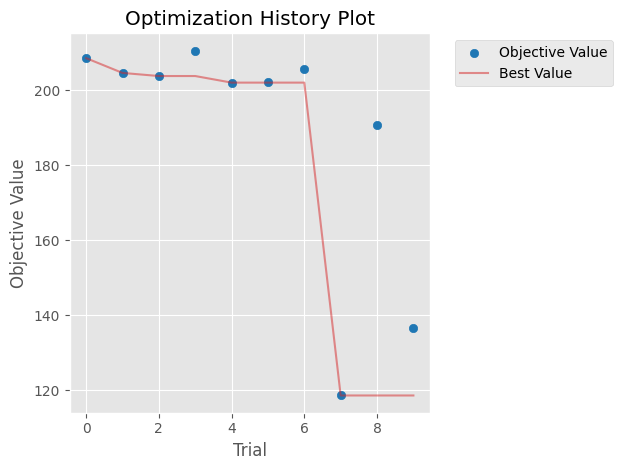

In [20]:
from optuna.visualization.matplotlib import plot_optimization_history
import matplotlib.pyplot as plt

# Plot the optimization history showing the objective value over trials
plot_optimization_history(study)
plt.show()


### Hyperparameter Importances
We can also visualize which hyperparameters had the biggest impact on the objective value.

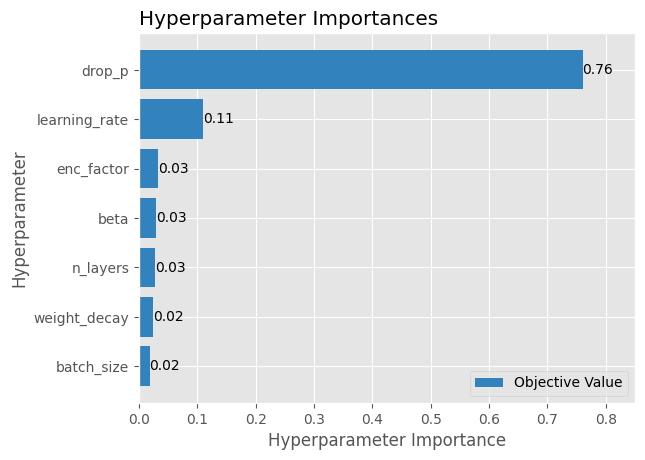

In [21]:
from optuna.visualization.matplotlib import plot_param_importances
import matplotlib.pyplot as plt

plot_param_importances(study)
plt.show()


### Comparing tuning on Reconstruction Loss vs. Downstream Performance

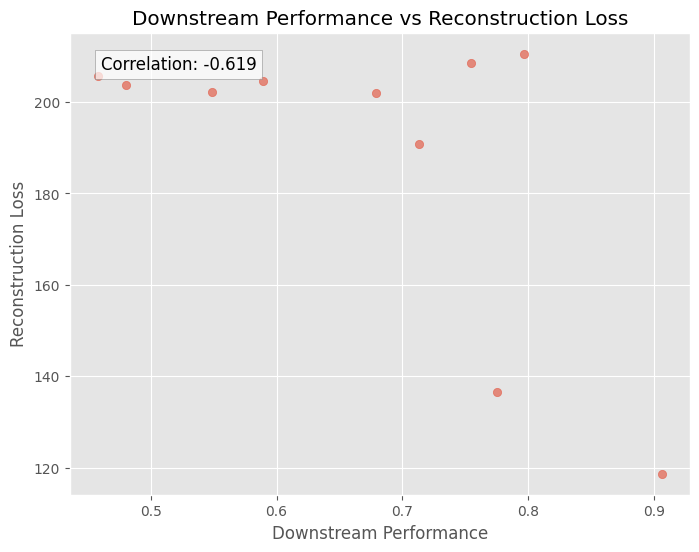

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from optuna.trial import TrialState

# Extract the metrics stored in user_attrs for all completed trials
completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]

y = [t.user_attrs.get("reconstruction_loss") for t in completed_trials]
x = [t.user_attrs.get("downstream_performance") for t in completed_trials]

corr = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("Downstream Performance")
plt.ylabel("Reconstruction Loss")
plt.title("Downstream Performance vs Reconstruction Loss")
# plt.xlim(0.8, 1.0) ## Limit to good and very good runs
# plt.ylim(500, 600) ##

plt.text(
	0.05, 0.95,
	f"Correlation: {corr:.3f}",
	transform=plt.gca().transAxes,
	fontsize=12,
	verticalalignment='top',
	bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.show()



## Selecting and Saving the Best Configuration

After the optimization finishes, we can query the study for the best configuration.
This configuration can then be reused for final training or further experiments.
We can also save the entire study using standard python `pickle` or Optuna's relational database (RDB) backends.

---

In [23]:
print(f"Best objective value: {study.best_value}")
print(f"Best configuration found: {study.best_params}")

import pickle

with open("optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)

print("Saved optuna_study.pkl")

with open("optuna_study.pkl", "rb") as f:
	loaded_study = pickle.load(f)
print("Loaded optuna_study.pkl")


Best objective value: 118.65896484375
Best configuration found: {'batch_size': 644, 'drop_p': 0.017430262083267367, 'enc_factor': 4, 'weight_decay': 7.022834985764343e-05, 'beta': 0.0003919944843607491, 'learning_rate': 0.0009253214657642581, 'n_layers': 2}
Saved optuna_study.pkl
Loaded optuna_study.pkl
